## Model evaluation and report
This notebook evaluates all U-Net models from base level on the Virginia Beach test set and the Frankfurt dataset, and report the results.  

**U-Net models from base level**
* Red-Green-Blue
* Red-Green-NIR
* NDVI-Red-NIR
* NDWI-Red-NIR
* Red-Green-Blue-NIR

**dataset**
* VBWVA test set (46 images)
* Frankfurt dataset (13 images)

## Setup
Set up file system for the datset(using Google Drive), dagshub and MLflow

In [1]:
# Install dependencies
%%capture
%pip install -q dagshub[jupyter]
!pip install mlflow
!pip install rasterio

In [2]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# Set up dagshub
!dagshub login
import dagshub
TOKEN = dagshub.auth.get_token()

Mounted at /content/drive
                                ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                                


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9efd4170-73a3-46c6-843a-e047cc892dec&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=f73259b44a6d81c70f481a41bd8f9ad98d1d0ba12c4fb4a4431ec7af1c2b9d89


⠼ Waiting for authorization
✅ OAuth token added


Accessing as chengzwk

## Data Preparation

In [3]:
# Import packages
import os
import sys
import rasterio
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from natsort import natsorted
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


def print_progress_bar(iteration, total, length=40):
    """Print a progress bar."""
    percent = (iteration / total) * 100
    filled_length = int(length * iteration // total)
    bar = '█' * filled_length + '-' * (length - filled_length)
    sys.stdout.write(f'\r|{bar}| {percent:.2f}%')
    sys.stdout.flush()

def compute_band_index(image_array, index_name):
    """
    NDVI = ((NIR - Red)/(NIR + Red))
    NDWI = (Green - NIR) / (Green + NIR)
    """
    band_blue = image_array[:, :, 0]
    band_green = image_array[:, :, 1]
    band_red = image_array[:, :, 2]
    band_nir = image_array[:, :, 3]

    if index_name == 'NDVI':
        return np.where((band_nir + band_red) != 0, (band_nir - band_red) / (band_nir + band_red), 0)
    elif index_name == 'NDWI':
        return np.where((band_green + band_nir) != 0, (band_green - band_nir) / (band_green + band_nir), 0)
    else:
        raise ValueError(f"Unknown index: {index_name}")

def select_bands(image_array, selected_bands=['Blue', 'Green', 'Red']):
    image_array = image_array.astype(np.float64)  # Convert dtype of image file from int to float64

    band_dict = {
        'Blue': image_array[:, :, 0],
        'Green': image_array[:, :, 1],
        'Red': image_array[:, :, 2],
        'NIR': image_array[:, :, 3],
        'NDVI': compute_band_index(image_array, 'NDVI'),
        'NDWI': compute_band_index(image_array, 'NDWI'),
    }

    selected_array = np.stack([band_dict[band] for band in selected_bands], axis=-1)
    return selected_array

def normalize_by_layer(image_array, selected_bands=['Blue', 'Green', 'Red']):
    """
    Function to normalize image data to the same max(1) and min(0)
    Since different layers(bands) have different scales, normalization will be done layer by layer
    """
    # Normalize by band
    # image_array = image_array.astype(np.float64)  # Convert dtype of image file from int to float64

    bands_indices = {'NDVI', 'NDWI'}

    for i, band in enumerate(selected_bands):
        if band in bands_indices:
            image_array[:, :, i] = (image_array[:, :, i] + 1) / 2  # Rescale band indices from [-1, 1] to [0, 1]
        else:
            layer_min = np.min(image_array[:, :, i])
            layer_max = np.max(image_array[:, :, i])

            try:
                image_array[:, :, i] = (image_array[:, :, i] - layer_min) / (layer_max - layer_min)
            except ZeroDivisionError:
                print(f"Band {i} has zero variation (min = max = {layer_min}). Skipping normalization.")
                image_array[:, :, i] = 0  # Set the band to default value 0

    return image_array

def convert_binary_mask(mask_array, multiclass=True, threshold=0.5):
    """
    Convert fractional mask to binary mask
    By default, convert it to multiclass mask of 5 classes
    Class numbers:
    0: Impervious surfaces and buildings
    1: Low vegetation
    2: Trees
    3: Water
    4: Clutter/Background
    """
    if multiclass:
        mask_array = np.argmax(mask_array, axis=2, keepdims=True)
    else:
        mask_array = ((mask_array[:, :, 1] + mask_array[:, :, 2]) >= threshold).astype(np.uint8)
        mask_array = mask_array[:, :, np.newaxis]
    return mask_array

def read_file(data_dir, image_dir, multiclass=True, threshold=0.5, subset_size=None, selected_bands=['Blue', 'Green', 'Red']):
    """
    Read satellite image files and corresponding masks as numpy arrays,
    normalize image array to the same scale by band, and convert fractional masks into binary masks.
    Read subset_size image files for training
    Note we're only using images from the same time (files ends in 1_GeoTIFF)
    """
    image_dataset = []
    mask_dataset = []
    mask_dir = image_dir + '_masks'
    image_files = [f for f in os.listdir(os.path.join(data_dir, image_dir)) if f.endswith('1_GeoTIFF.tif')]
    image_files = natsorted(image_files)
    if subset_size is not None:
        image_files = image_files[:subset_size]
    total_files = len(image_files)

    # Print progress
    print(f"Reading images and masks from {image_dir} and {mask_dir}, selected bands={selected_bands}")

    for i, image_file in enumerate(image_files):
        mask_file = image_file.replace('.tif', '_fractional_mask.tif')
        image_path = os.path.join(data_dir, image_dir, image_file)
        mask_path = os.path.join(data_dir, mask_dir, mask_file)

        # Read image file
        with (rasterio.open(image_path) as img):
            image_array = img.read()
        image_array = np.transpose(image_array, [1, 2, 0])                            # move the axis for bands to the third axis
        image_array[np.isnan(image_array)] = 0                                        # replace nan with 0
        image_array = image_array[:, :, (1, 2, 3, 7)]                                 # get the bands you want; (1, 2, 3, 7) is Blue, Green, Red, NIR
        image_array = select_bands(image_array, selected_bands=selected_bands)        # Compute band indices and select bands
        image_array = normalize_by_layer(image_array, selected_bands=selected_bands)  # Normalize the image by band

        # Read mask file
        with rasterio.open(mask_path) as msk:
            mask_array = msk.read()
        mask_array = np.transpose(mask_array, [1, 2, 0])          # move the axis for bands to the third axis
        mask_array[np.isnan(mask_array)] = 0                           # replace nan with 0
        mask_array = convert_binary_mask(mask_array, multiclass=multiclass, threshold=threshold)  # Convert fractional mask to binary

        image_dataset.append(image_array)
        mask_dataset.append(mask_array)

        # Print progress
        print_progress_bar(i + 1, total_files)  # Update progress bar

    image_dataset = np.array(image_dataset)
    mask_dataset = np.array(mask_dataset)
    mask_dataset = mask_dataset.astype(np.float64)  # Convert dtype of mask file from int to float64

    # Print and log progress
    print("\nFinished reading images")

    return image_dataset, mask_dataset

def remove_images(image_dataset, mask_dataset, threshold):
    """
    This function remove images and corresponding masks with high proportion of backgrounds
    Definition of backgrounds:
        - urban green space: classes 3 and 4
        - backgrounds: classes 2, 5, and 6
    Input:
        - image_dataset, mask_dataset: numpy array of satellite images and corresponding masks
        - threshold: if proportion of backgrounds is higher than threshold in the image, the image will be removed
    Output:
        - balanced array without those chips
    """
    # Get the id of images to remove
    id_to_remove = []

    for i in range(len(mask_dataset)):
        mask = mask_dataset[i, :, :, 0]
        tot_pixel = mask.size
        background_pixel = np.count_nonzero(np.isin(mask, [2, 5, 6]))
        if background_pixel > tot_pixel * threshold:
            id_to_remove.append(i)

    # Get the balanced dataset
    image_dataset_balanced = []
    mask_dataset_balanced = []

    for i in range(len(image_dataset)):
        if not(i in id_to_remove):
            image = image_dataset[i]
            mask = mask_dataset[i]
            image_dataset_balanced.append(image)
            mask_dataset_balanced.append(mask)

    image_dataset_balanced = np.array(image_dataset_balanced)
    mask_dataset_balanced = np.array(mask_dataset_balanced)

    return image_dataset_balanced, mask_dataset_balanced

def show_statistics(image_dataset, mask_dataset):
    print("Image data shape is: ", image_dataset.shape)
    print("Mask data shape is: ", mask_dataset.shape)
    print("Max pixel value in image is: ", image_dataset.max())
    print("Min pixel value in image is: ", image_dataset.min())
    print("Labels in the mask are : ", np.unique(mask_dataset))

    multiclass = len(np.unique(mask_dataset)) > 2
    total_pixels = mask_dataset.size  # Get total number of pixels in the dataset

    if multiclass:
        for i in range(5):
            count = np.count_nonzero(mask_dataset == i)
            percentage = (count / total_pixels) * 100
            print(f"Number of pixels in class {i}: {count} ({percentage:.2f}%)")

        background_count = np.count_nonzero(np.isin(mask_dataset, [0, 3, 4]))
        background_percentage = (background_count / total_pixels) * 100
        print(f"Number of background pixels: {background_count} ({background_percentage:.2f}%)")

        low_veg_count = np.count_nonzero(mask_dataset == 1)
        low_veg_percentage = (low_veg_count / total_pixels) * 100
        print(f"Number of low vegetation pixels: {low_veg_count} ({low_veg_percentage:.2f}%)")

        tree_count = np.count_nonzero(mask_dataset == 2)
        tree_percentage = (tree_count / total_pixels) * 100
        print(f"Number of tree pixels: {tree_count} ({tree_percentage:.2f}%)")

    else:
        non_veg_count = np.count_nonzero(mask_dataset == 0)
        non_veg_percentage = (non_veg_count / total_pixels) * 100
        print(f"Number of non-vegetation pixels: {non_veg_count} ({non_veg_percentage:.2f}%)")

        veg_count = np.count_nonzero(mask_dataset == 1)
        veg_percentage = (veg_count / total_pixels) * 100
        print(f"Number of vegetation pixels: {veg_count} ({veg_percentage:.2f}%)")

def inspect_dataset(image_dataset, mask_dataset, sample_size=2):
    """
    Randomly select and plot sample_size images and corresponding binary masks for visual inspection
    """
    # Randomly select sample_size files
    samples = random.sample(list(np.arange(len(image_dataset))), min(sample_size, len(image_dataset)))
    sample_images = [image_dataset[i, :, :, :] for i in samples]
    sample_masks = [mask_dataset[i, :, :, :] for i in samples]
    multiclass = len(np.unique(mask_dataset)) > 2

    # Display the randomly selected images and masks
    for i in range(len(sample_images)):
        if multiclass:
            class_labels = {
                0: "Class 1&2: impervious",
                1: "Class 3: low veg",
                2: "Class 4: trees",
                3: "Class 5: water",
                4: "Class 6: clutter"}

            class_colors = {
                0: "#808080",  # Gray
                1: "#ADFF2F",  # Light Green
                2: "#006400",  # Dark Green
                3: "#1E90FF",  # Blue
                4: "#8B4513",  # Brown
            }

            cmap = plt.cm.colors.ListedColormap([class_colors[c] for c in sorted(class_colors)])
            norm = plt.cm.colors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
                                              ncolors=5)  # Use a discrete colormap
        else:
            class_labels = {
                0: "Class 0: non-vegetation",
                1: "Class 1: vegetation",
            }

            class_colors = {
                0: "#808080",  # Gray
                1: "#006400",  # Dark Green
            }

            cmap = plt.cm.colors.ListedColormap([class_colors[c] for c in sorted(class_colors)])
            norm = plt.cm.colors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5],
                                              ncolors=2)  # Use a discrete colormap

        fig = plt.figure(figsize=(12, 5))
        gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.6])  # Adjust width ratios

        ax0 = fig.add_subplot(gs[0])  # Satellite image
        ax1 = fig.add_subplot(gs[1])  # Mask
        ax_legend = fig.add_subplot(gs[2])  # Legend axes

        # Plot satellite image
        ax0.imshow(sample_images[i][:, :, :3])
        ax0.set_title("Satellite Image")
        ax0.axis("off")
        # Plot mask
        ax1.imshow(sample_masks[i], cmap=cmap, norm=norm)
        ax1.set_title("Mask")
        ax1.axis("off")

        # Create legend (same as before)
        handles = [mpatches.Patch(color=class_colors[key], label=class_labels[key]) for key in sorted(class_labels)]
        ax_legend.legend(handles=handles, loc='center left', title='Legend')
        ax_legend.axis('off')  # Hide legend axes ticks and labels

        # Manually adjust subplot parameters for better spacing
        gs.update(wspace=0.05, hspace=0.05)  # Adjust spacing here
        plt.show()

def split_dataset(image_dataset, mask_dataset, test_size=0.15, val_size=0.15, random_state=42):
    """Split dataset into train, validation, and test sets."""

    # First, split off the test set
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        image_dataset, mask_dataset, test_size=test_size, random_state=random_state
    )

    # Then, split train_val into actual train and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size / (1 - test_size), random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

def categorical_mask_dataset(y_train, num_classes=2):
    """Turns mask dataset (y_train, y_val, y_test) into categorical (one-hot encoded) format."""
    y_train_cat = to_categorical(y_train, num_classes=num_classes)
    return y_train_cat

def formatted_print_shapes(X_train, X_val, X_test, y_train, y_val, y_test):
    """
    Prints the shapes of training, validation, and test data in a formatted way.
    Also prints steps per epoch and validation steps if provided.
    """
    print("Data Shapes:")
    print("-" * 20)
    print(f"X_train: {X_train.shape}")
    print(f"X_val:   {X_val.shape}")
    print(f"X_test:  {X_test.shape}")
    print("-" * 20)
    print(f"y_train: {y_train.shape}")
    print(f"y_val:   {y_val.shape}")
    print(f"y_test:  {y_test.shape}")
    print("-" * 20)


In [ ]:
def cropping_coordinates(h, w, crop_size):
    """
    Calculate cropping coordinates of image file
    """
    top = (h - crop_size) // 2
    left = (w - crop_size) // 2
    bottom = top + crop_size
    right = left + crop_size

    return top, left, bottom, right

def crop_image(image, crop_size=128):
    """Crop the image and mask to 128x128 pixels from the center."""
    if image.shape[1:] != (crop_size, crop_size):
        h, w = image.shape[1:]  # Get height and width from the image dimensions
        top, left, bottom, right = cropping_coordinates(h, w, crop_size)
        cropped_image = image[:, top:bottom, left:right]  # Keep all bands
    return cropped_image

def read_file_frankfurt(data_dir, image_dir, mask_dir, multiclass=True, threshold=0.5, subset_size=None, crop_size=128, selected_bands=['Blue', 'Green', 'Red']):
    """
    Read satellite image files and corresponding masks as numpy arrays,
    normalize image array to the same scale by band, and convert fractional masks into binary masks.
    Read subset_size image files for training
    Note we're only using images from the same time (files ends in 1_GeoTIFF)
    """
    image_dataset = []
    mask_dataset = []
    # mask_dir = image_dir + '_masks'
    image_files = [f for f in os.listdir(os.path.join(data_dir, image_dir)) if f.endswith('.tif')]
    image_files = natsorted(image_files)
    mask_files = [f for f in os.listdir(os.path.join(data_dir, mask_dir)) if f.endswith('.tif')]
    mask_files = natsorted(mask_files)
    if subset_size is not None:
        image_files = image_files[:subset_size]
    total_files = len(image_files)

    # Print progress
    print(f"Reading images and masks from {image_dir} and {mask_dir}, selected bands={selected_bands}")

    for i, image_file in enumerate(image_files):
        # mask_file = image_file.replace('.tif', '_fractional_mask.tif')
        mask_file = mask_files[i]
        image_path = os.path.join(data_dir, image_dir, image_file)
        mask_path = os.path.join(data_dir, mask_dir, mask_file)

        # Read image file
        with (rasterio.open(image_path) as img):
            image_array = img.read()
        image_array = crop_image(image_array)
        image_array = np.transpose(image_array, [1, 2, 0])                            # move the axis for bands to the third axis
        image_array[np.isnan(image_array)] = 0                                        # replace nan with 0
        image_array = image_array[:, :, (1, 2, 3, 7)]                                 # get the bands you want; (1, 2, 3, 7) is Blue, Green, Red, NIR
        image_array = select_bands(image_array, selected_bands=selected_bands)        # Compute band indices and select bands
        image_array = normalize_by_layer(image_array, selected_bands=selected_bands)  # Normalize the image by band

        # Read mask file
        with rasterio.open(mask_path) as msk:
            mask_array = msk.read()
        mask_array = crop_image(mask_array)
        mask_array = np.transpose(mask_array, [1, 2, 0])          # move the axis for bands to the third axis
        mask_array[np.isnan(mask_array)] = 0                           # replace nan with 0
        # mask_array = convert_binary_mask(mask_array, multiclass=multiclass, threshold=threshold)  # Convert fractional mask to binary
        mask_array = normalize_by_layer(mask_array)

        image_dataset.append(image_array)
        mask_dataset.append(mask_array)

        # Print progress
        print_progress_bar(i + 1, total_files)  # Update progress bar

    image_dataset = np.array(image_dataset)
    mask_dataset = np.array(mask_dataset)
    mask_dataset = mask_dataset.astype(np.float64)  # Convert dtype of mask file from int to float64

    # Print and log progress
    print("\nFinished reading images")

    return image_dataset, mask_dataset

## Model Evaluation and Prediction

In [ ]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.metrics import IoU, MeanIoU
from sklearn.metrics import roc_curve, auc
import matplotlib.patches as mpatches


def calculate_f1_score(precision, recall):
    """Calculates the F1 score and avoids division by zero."""
    denominator = precision + recall
    if denominator == 0:
        f1_score = 0.0
    else:
        f1_score = 2 * precision * recall / (precision + recall)
    return f1_score

def predict(model, X_test, threshold=0.5):
    """Generate predictions and apply thresholding."""
    y_pred = model.predict(X_test)
    # y_pred = model(X_test, training=True)
    y_pred = tf.sigmoid(y_pred).numpy()
    y_pred_thresholded = (y_pred >= threshold).astype(int)

    return y_pred, y_pred_thresholded

def evaluate_model(model, X_test, y_test):
    """Evaluate model on test set and return loss, accuracy, precision, and recall."""
    loss, acc, precision, recall, mean_iou, iou_class1 = model.evaluate(X_test, y_test, verbose=0)
    f1_score = calculate_f1_score(precision, recall)

    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"IoU for class 1: {iou_class1:.4f}")

    return loss, acc, precision, recall, f1_score, mean_iou, iou_class1

def compute_iou(y_pred_thresholded, y_test):
    """Compute IoU for class 1 and Mean IoU."""
    iou_metric = IoU(num_classes = 2, target_class_ids=[1])
    mean_iou_metric = MeanIoU(num_classes = 2)

    iou_metric.update_state(y_pred_thresholded, y_test)
    mean_iou_metric.update_state(y_pred_thresholded, y_test)

    iou_value = iou_metric.result().numpy()
    mean_iou_value = mean_iou_metric.result().numpy()

    print(f"IoU for class 1: {iou_value:.4f}")
    print(f"Mean IoU: {mean_iou_value:.4f}")

    return iou_value, mean_iou_value

def plot_roc_curve(y_pred_thresholded, y_test, result_dir=None, ifplot=True):
    """Plot ROC curve and compute AUC."""
    y_test_raveled = y_test.ravel().astype(int)
    y_pred_thresholded_raveled = y_pred_thresholded.ravel().astype(int)

    fpr, tpr, thresholds = roc_curve(y_test_raveled, y_pred_thresholded_raveled)
    auc_value = auc(fpr, tpr)

    if ifplot:
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.grid()
        plt.savefig(os.path.join(result_dir, "ROC_curve.png"))

        print(f"AUC: {auc_value:.4f}")
    return auc_value

def visualize_predictions(X, y_true, y_pred, result_dir=None, title="Predictions vs. Ground Truth", num_samples=None):
    """Helper function to visualize predictions against ground truth."""
    if num_samples is None:
        num_samples = X.shape[0]
        sample_indices = range(len(X))
    else:
        sample_indices = random.sample(range(len(X)), num_samples)
        
    fig, axes = plt.subplots(num_samples, 4, figsize=(12, 5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)  # Ensure consistent indexing

    for i in sample_indices:
        axes[i, 0].imshow(X[i])
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(y_true[i].squeeze(), cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(y_pred[i].squeeze(), cmap="gray")
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(result_dir, f"{title}.png"))
    # plt.close()

def visualize_prediction_comparison(X, y_true, y_pred, result_dir=None, title="Prediction Comparison", num_samples=None):
    """
    Visualizes the comparison between the predicted mask and the ground truth.
    
    Green: Correctly predicted vegetation (intersection of prediction and ground truth).
    Red: False positives (predicted vegetation that is not in the ground truth).
    Blue: False negatives (missed vegetation in ground truth but not predicted).
    
    Parameters:
        X (numpy array): Input images.
        y_true (numpy array): Ground truth masks (binary).
        y_pred (numpy array): Predicted masks (binary).
        result_dir (str): Directory to save the visualization.
        title (str): Title of the plot.
    """
    if num_samples is None:
        num_samples = X.shape[0]
        sample_indices = range(len(X))
    else:
        sample_indices = random.sample(range(len(X)), num_samples)
        
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)  # Ensure consistent indexing

    # Define color mapping (single-channel image with unique color values)
    COLOR_MAPPING = {
        0: (0, 0, 0),        # Black (Background)
        1: (76/255, 175/255, 80/255),   # Green (True Positive)
        2: (244/255, 67/255, 54/255),   # Red (False Positive)
        3: (255/255, 152/255, 0/255)    # Orange (False Negative)
    }

    for i in sample_indices:
        # Compute error visualization
        comparison_mask = np.zeros_like(y_true[i], dtype=np.uint8)

        intersection = (y_true[i] == 1) & (y_pred[i] == 1)  # True Positive (Green)
        false_positive = (y_true[i] == 0) & (y_pred[i] == 1)  # False Positive (Red)
        false_negative = (y_true[i] == 1) & (y_pred[i] == 0)  # False Negative (Orange)

        comparison_mask[intersection] = 1
        comparison_mask[false_positive] = 2
        comparison_mask[false_negative] = 3

        # Create a custom colormap
        colormap = np.zeros((4, 3))  # 4 unique values (0-3)
        for key, color in COLOR_MAPPING.items():
            colormap[key] = color

        # Plot original image
        axes[i, 0].imshow(X[i][:, :, :3])  # Show only RGB channels
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        # Plot comparison mask with assigned colors
        axes[i, 1].imshow(comparison_mask, cmap=plt.cm.colors.ListedColormap(colormap))
        axes[i, 1].set_title("Prediction Comparison")
        axes[i, 1].axis("off")

    # Create a legend
    legend_patches = [
        mpatches.Patch(color=COLOR_MAPPING[1], label="Correct Vegetation (True Positive)"),
        mpatches.Patch(color=COLOR_MAPPING[2], label="False Positive"),
        mpatches.Patch(color=COLOR_MAPPING[3], label="False Negative")
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=2, fontsize=12)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.1, 1, 1])  # Adjust layout to fit legend
    plt.show()

def run_evaluation(model, X_test, y_test, result_dir):
    """Run all evaluation steps."""
    print("Model Evaluation")
    print("-" * 20)

    # Prediction
    y_pred, y_pred_thresholded = predict(model, X_test)

    # Evaluate model performance
    evaluate_model(model, X_test, y_test)

    # Compute IoU
    # compute_iou(y_pred_thresholded, y_test)

    # Plot ROC curve and compute AUC
    plot_roc_curve(y_pred_thresholded, y_test, result_dir)

    # Visualize predictions vs. ground truth
    visualize_predictions(X_test, y_test, y_pred_thresholded, result_dir, title="Final Predictions")


## Visualize models evaluation results

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visualize_eval_results(df_eval, metrics, title)        
    # Sort models by Overall Accuracy (OA) for better readability
    df_eval = df_eval.sort_values(by="OA", ascending=False)
    
    # Set a modern color palette
    sns.set_style("whitegrid")
    palette = sns.color_palette("Set2", len(metrics))
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    df_eval.set_index("Combination of bands")[metrics].plot(kind="bar", ax=ax, color=palette, width=0.8)
    
    # Add titles and labels
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_xlabel("Combination of Bands")
    ax.set_xticklabels(df_eval["Combination of bands"], rotation=30, ha="right")
    
    # Add value labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.2f}", (p.get_x() + p.get_width() / 2., height),
                        ha="center", va="bottom", fontsize=10)
    
    # Move the legend outside to avoid clutter
    ax.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    # Show plot
    plt.tight_layout()
    plt.show()


## Evaluation on VBWVA test set

Reading images and masks from VBWVA_8R and VBWVA_8R_masks
|████████████████████████████████████████| 100.00%
Finished reading images


                           Experiment      Loss  Accuracy  Precision  \
7  experiment08_decrease_weight_decay  0.095821  0.794994   0.867323   
6       experiment07_add_weight_decay  0.098213  0.792471   0.841532   
1      experiment02_data_augmentation  0.110099  0.790627   0.828041   
5  experiment06_decrease_dropout_rate  0.094816  0.788975   0.863951   
3    experiment04_decrease_batch_size  0.093722  0.785979   0.871853   
8  experiment09_increase_weight_decay  0.098523  0.784982   0.875252   
0       experiment01_add_stlouis_data  0.166664  0.781054   0.852785   
9              overfitting-experiment  0.415600  0.773900   0.806800   
4            experiment05_add_dropout  0.098409  0.765820   0.879204   
2         experiment03_early_stopping  0.111526  0.754000   0.853478   

     Recall  IoU (All Classes)  IoU (Class 1)  F1-score       AUC  
7  0.859216           0.701728       0.759403  0.809298  0.911289  
6  0.883746           0.687900       0.757659  0.808813  0.906354  
1  

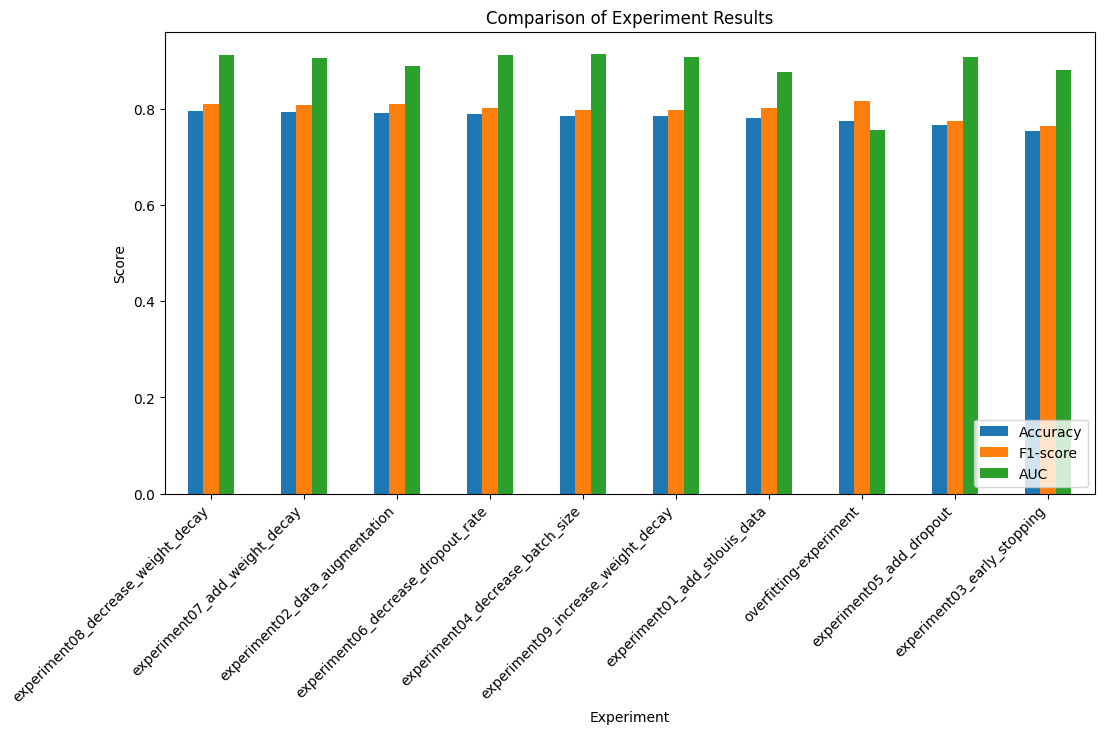

In [4]:
import os
import numpy as np
import pandas as pd
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score


# --- Reload VBWVA test set ---
data_dir = "/content/drive/MyDrive/Omdena/urban-green-frankfurt/MULC"
image_dir = 'VBWVA_8R'
bands = ['Green', 'Red', 'NIR']  # Choose a combination of 3 bands from Blue, Green, Red, NIR, NDVI, NDWI
image_dataset, mask_dataset = read_file(
    data_dir,
    image_dir,
    multiclass=False,
    selected_bands=bands
)

# Train-validation-test split
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(image_dataset, mask_dataset)
del image_dataset, mask_dataset
formatted_print_shapes(X_train, X_val, X_test, y_train, y_val, y_test)


# --- Load U-Net models ---
# Define base directory
base_dir = "/content/drive/MyDrive/band_combinations"

# Define model directories
model_dirs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])

# Dictionary to store evalutation results
eval_results = []

# Loop through each model
for model_id in model_dirs:
    model_dir = os.path.join(base_dir, model_id)
    model_path = os.path.join(model_dir, "best_model_unet.keras")

    # Load model with compiling
    model = load_model(model_path, compile=True)

    # Evaluate model on test set
    y_pred, y_pred_thresholded = predict(model, X_test)
    loss, acc, precision, recall, f1_score, mean_iou, iou_class1 = evaluate_model(model, X_test, y_test)
    auc = plot_roc_curve(y_pred_thresholded, y_test, result_dir, ifplot=False)
    
    # Store results
    eval_results.append({
        "Combination of bands": '-'.join(model_id.split('_')[1:]),
        "Loss": loss,
        "OA": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1_score,
        "Mean IoU": mean_iou,
        "IoU (Veg)": iou_class1,
        "AUC": auc
    })

# Convert results to a DataFrame
df_eval = pd.DataFrame(eval_results)
# df_eval = df_eval.sort_values(by="OA", ascending=False)  # Sort by accuracy

# Visualize evaluation results
metrics = ["OA", "F1-score", "Mean IoU"]  # Select metrics for visualization
title = "Comparison of Model Performance on VBWVA test set"
visualize_eval_results(df_eval, metrics, title) 


In [ ]:
# Display results
df_eval

## Visualize Predictions on VBWVA test set

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


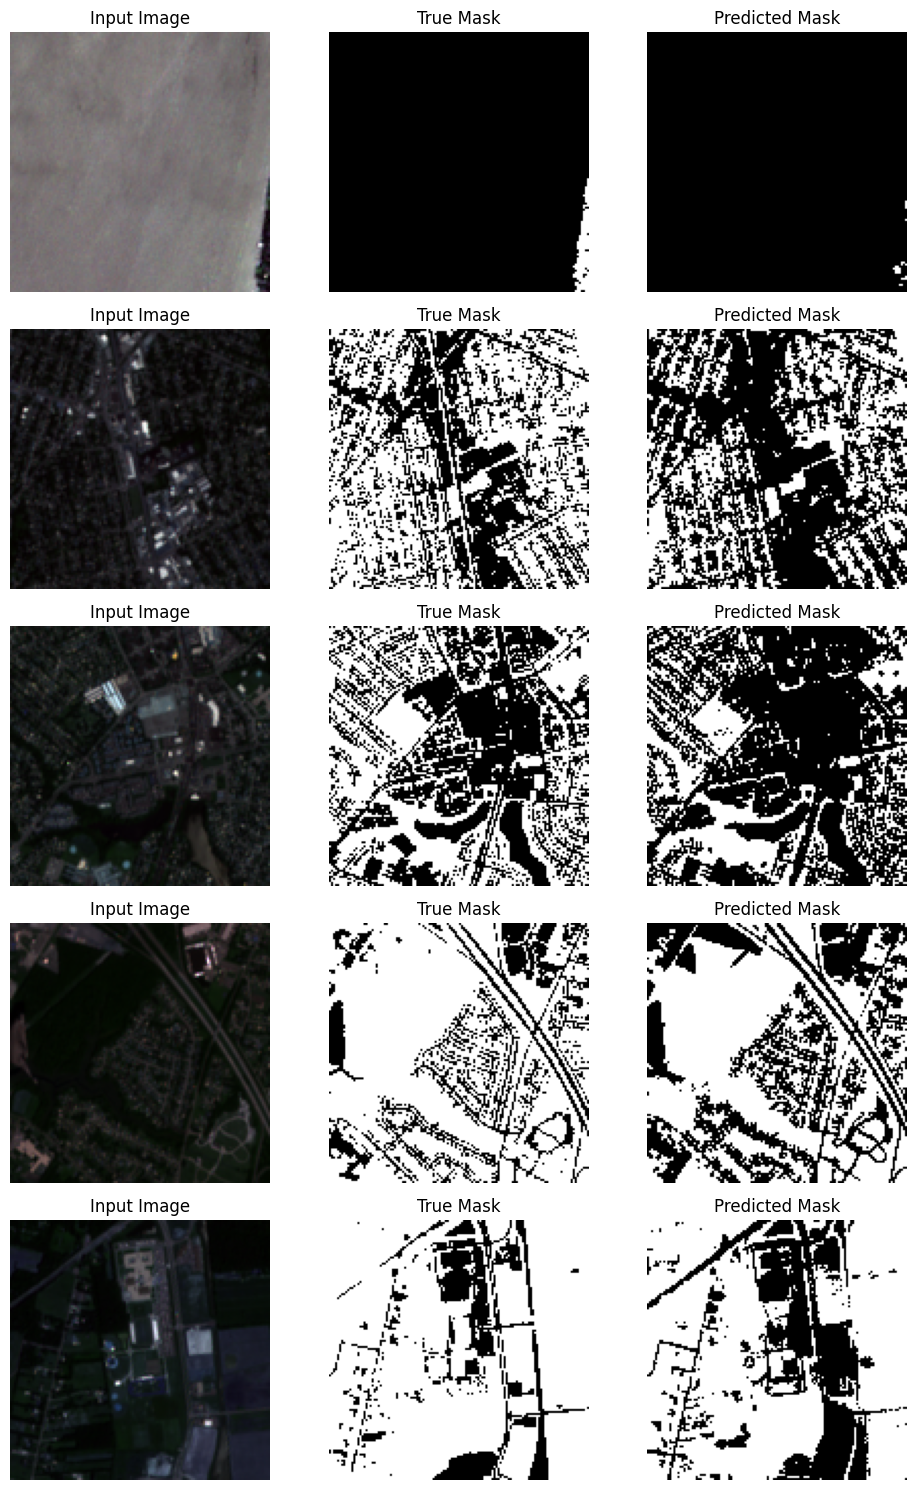

In [ ]:
visualize_predictions(X_test, y_test, y_pred_thresholded, title="Predictions on VBWVA test images", num_samples=5)
visualize_prediction_comparison(X_test, y_test, y_pred_thresholded, 
                                title="Comparison of Prediction and Ground Truth on VBWVA test images", 
                                num_samples=5)


## Evaluation on Frankfurt dataset

In [ ]:
import os
import numpy as np
import pandas as pd
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score


# --- Load and prepare Frankfurt dataset ---
data_dir = "/content/drive/MyDrive/Omdena/urban-green-frankfurt/Frankfurt"
image_dir = '01_Sentinel-2_medianImage_April-June_2021'
mask_dir = '02_Binary_FFM_downscaled_10m'
bands = ['Green', 'Red', 'NIR']  # Choose a combination of 3 bands from Blue, Green, Red, NIR, NDVI, NDWI
image_dataset, mask_dataset = read_file_frankfurt(
    data_dir,
    image_dir,
    mask_dir, 
    multiclass=False,
    selected_bands=bands
)

# Print statistics of the dataset and visually inspect the dataset
show_statistics(image_dataset, mask_dataset)
inspect_dataset(image_dataset, mask_dataset)

X_test = image_dataset
y_test = mask_dataset

# --- Load U-Net models ---
# Define base directory
base_dir = "/content/drive/MyDrive/band_combinations"

# Define model directories
model_dirs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])

# Dictionary to store evalutation results
frankfurt_results = []

# Loop through each model
for model_id in model_dirs:
    model_dir = os.path.join(base_dir, model_id)
    model_path = os.path.join(model_dir, "best_model_unet.keras")

    # Load model with compiling
    model = load_model(model_path, compile=True)

    # Evaluate model on test set
    y_pred, y_pred_thresholded = predict(model, X_test)
    loss, acc, precision, recall, f1_score, mean_iou, iou_class1 = evaluate_model(model, X_test, y_test)
    auc = plot_roc_curve(y_pred_thresholded, y_test, result_dir, ifplot=False)
    
    # Store results
    frankfurt_results.append({
        "Combination of bands": '-'.join(model_id.split('_')[1:]),
        "Loss": loss,
        "OA": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1_score,
        "Mean IoU": mean_iou,
        "IoU (Veg)": iou_class1,
        "AUC": auc
    })

# Convert results to a DataFrame
df_frankfurt = pd.DataFrame(frankfurt_results)
# df_eval = df_eval.sort_values(by="OA", ascending=False)  # Sort by accuracy

# Visualize evaluation results
metrics = ["OA", "F1-score", "Mean IoU"]  # Select metrics for visualization
title = "Comparison of Model Performance on Frankfurt Dataset"
visualize_eval_results(df_eval, metrics, title) 


In [ ]:
# Display results
df_frankfurt

## Visualize Predictions on Frankfurt dataset

In [ ]:
visualize_predictions(X_test, y_test, y_pred_thresholded, title="Predictions on Frankfurt images")
visualize_prediction_comparison(X_test, y_test, y_pred_thresholded, 
                                title="Comparison of Prediction and Ground Truth on Frankfurt images")

## Commit notebook to dagshub

In [10]:
commit_message = "Evaluate models on VBWVA test set and Frankfurt dataset, report results"

In [ ]:
from dagshub.notebook import save_notebook

repo = "chengzwk/omdena-frankfurt-ugs-unet"
branch = "main"
notebook_path = "models_evaluation_report_metrics.ipynb"

save_notebook(
    repo=repo,
    branch=branch,
    path=notebook_path,
    commit_message=commit_message,
    versioning="git"
    )